In [1]:
from service.datasetservice.DatasetService import DatasetService

dataset_service = DatasetService()
data = dataset_service.load_original_dataset()
data = data.ffill().bfill()
data.head()

,Participant,HR,respr,Time(sec),Label
0,2,118.00,12.127693,1644227583,0
1,2,113.50,12.127693,1644227584,0
2,2,93.00,12.127693,1644227585,0
3,2,93.25,12.127693,1644227586,0
4,2,86.40,12.127693,1644227587,0


In [2]:
# Get unique participants
participants = data['Participant'].unique()
# participants = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

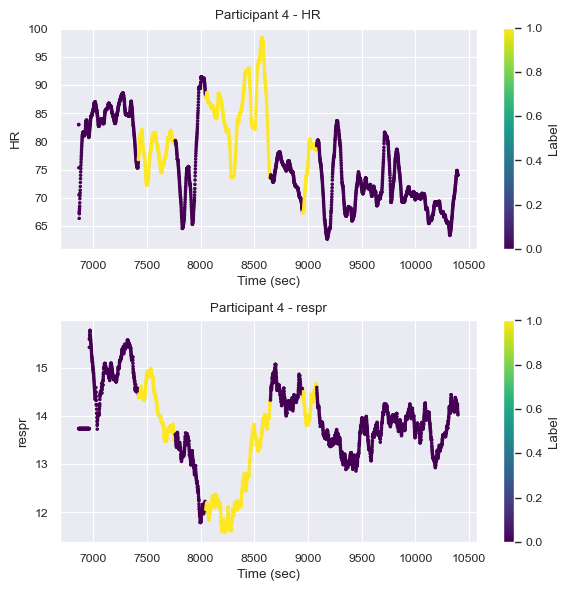

In [60]:
from matplotlib import pyplot as plt

participant = 4

participant_data = data[data['Participant'] == participant]

plt.figure(figsize=(6, 6))

# Plot HR with label color
plt.subplot(2, 1, 1)
scatter = plt.scatter(participant_data.index, participant_data['HR'], c=participant_data['Label'], cmap='viridis', s=3)
plt.title(f'Participant {participant} - HR')
plt.xlabel('Time (sec)')
plt.ylabel('HR')
plt.colorbar(scatter, label='Label')

# Plot respr with label color
plt.subplot(2, 1, 2)
scatter = plt.scatter(participant_data.index, participant_data['respr'], c=participant_data['Label'], cmap='viridis', s=3)
plt.title(f'Participant {participant} - respr')
plt.xlabel('Time (sec)')
plt.ylabel('respr')
plt.colorbar(scatter, label='Label')

plt.tight_layout()
plt.savefig("./fig.png")
plt.show()

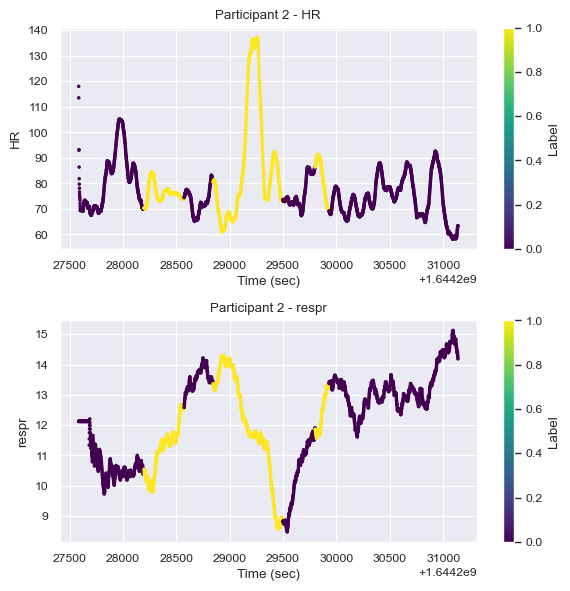

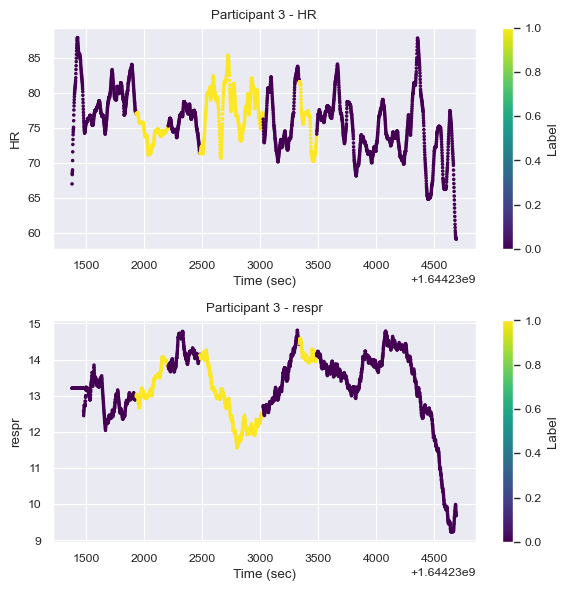

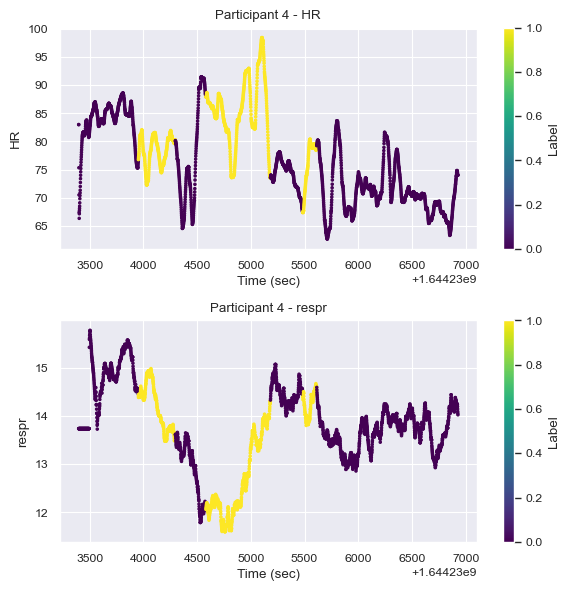

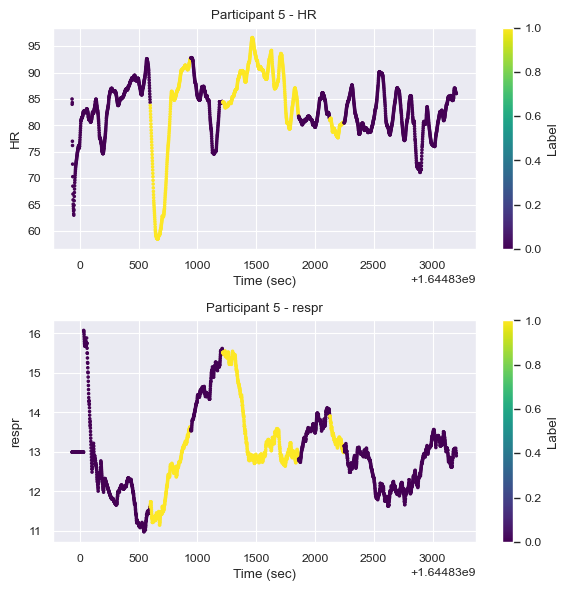

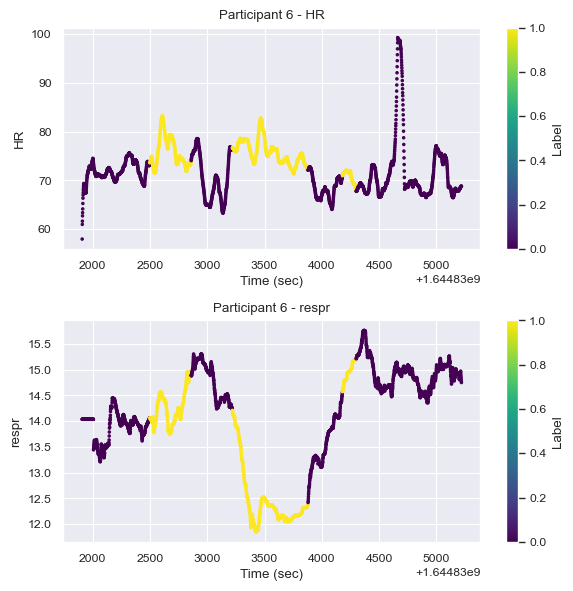

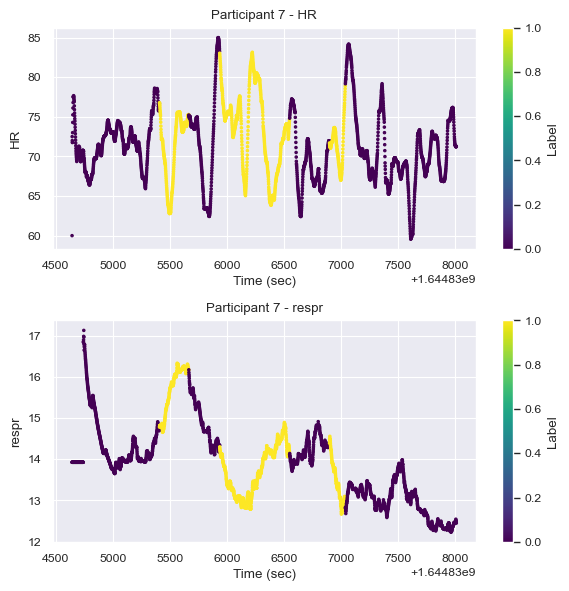

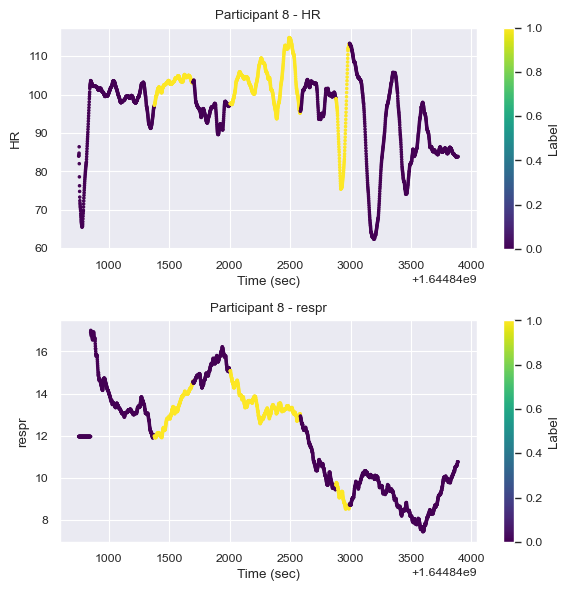

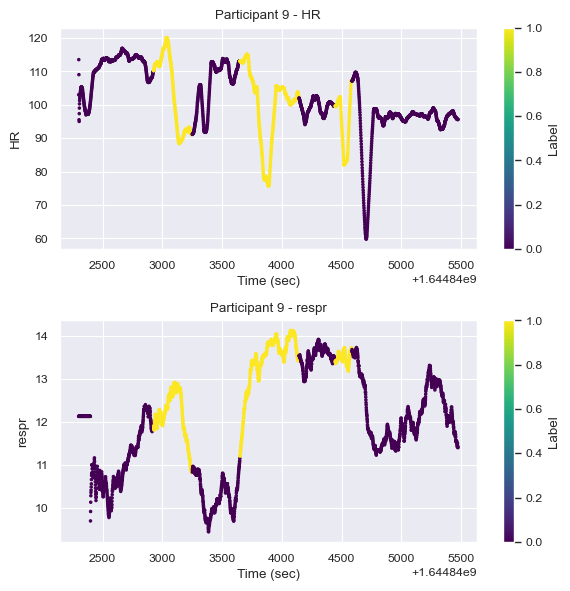

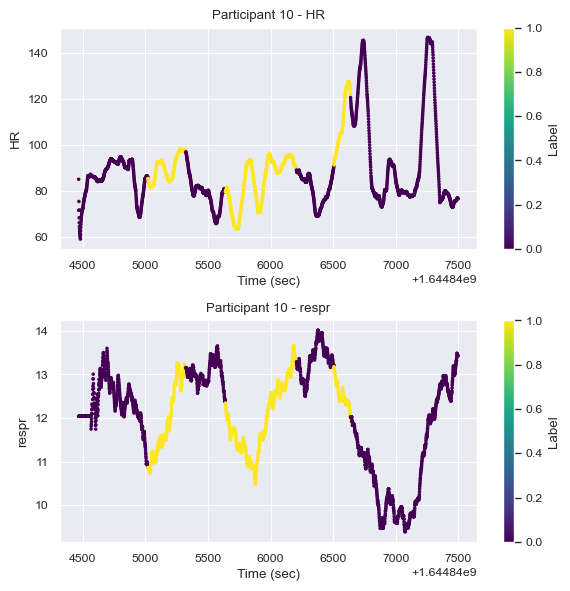

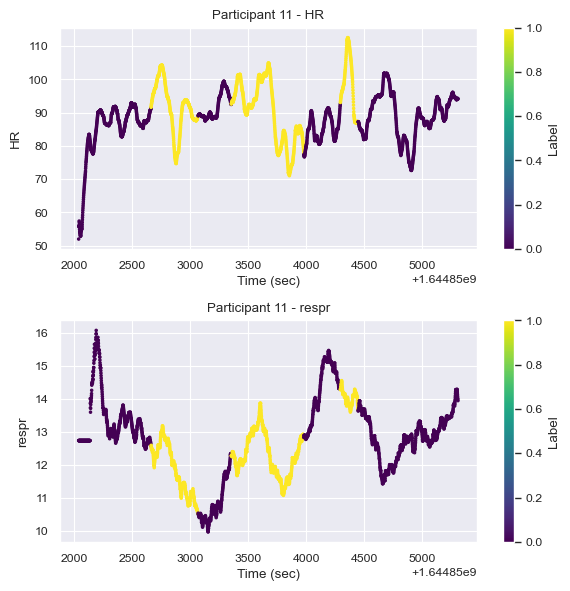

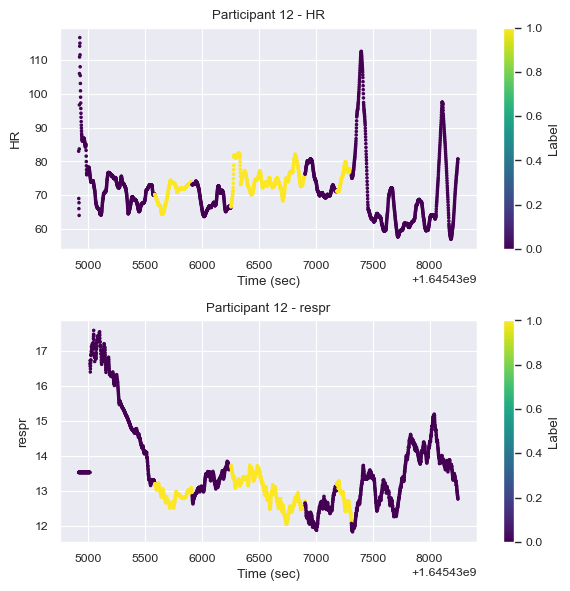

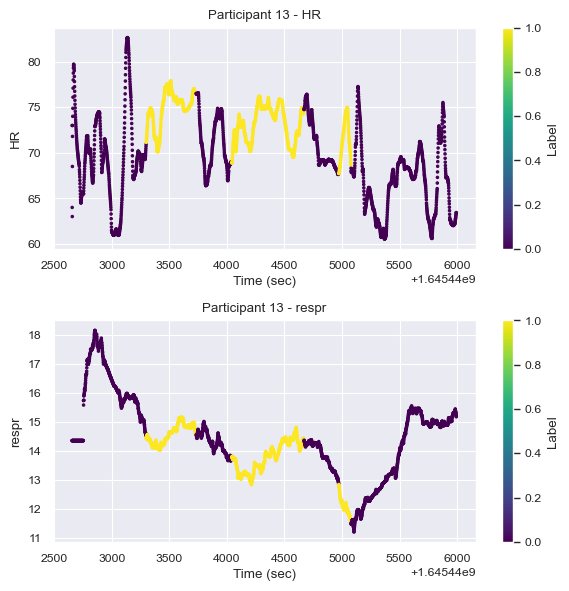

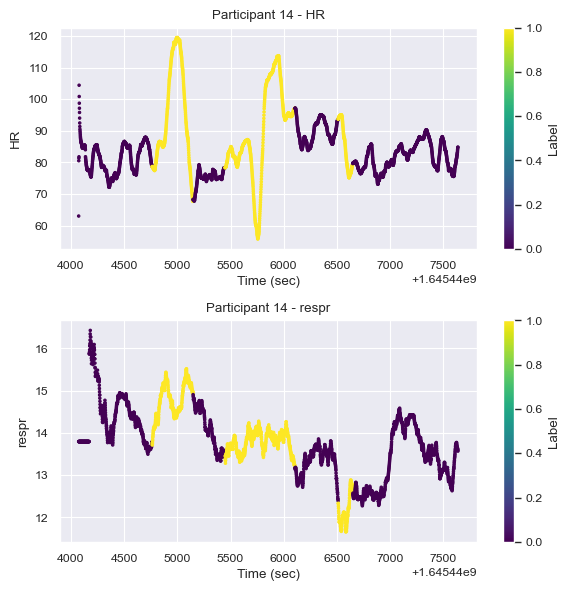

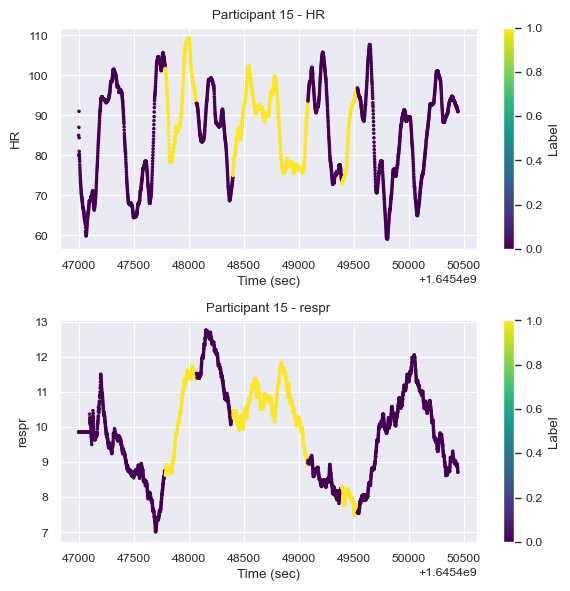

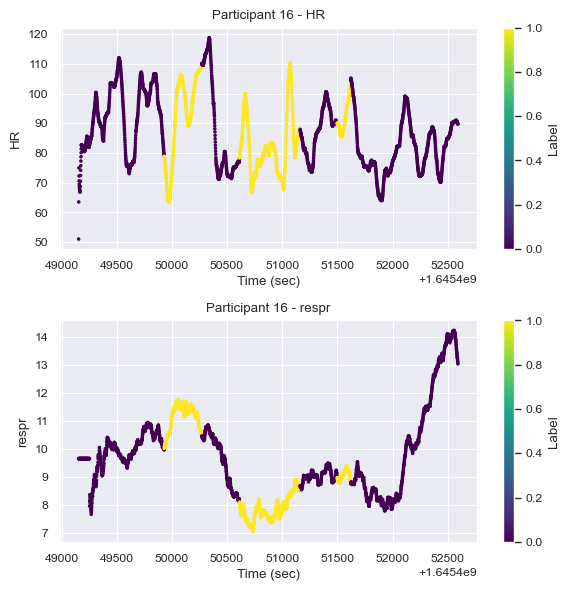

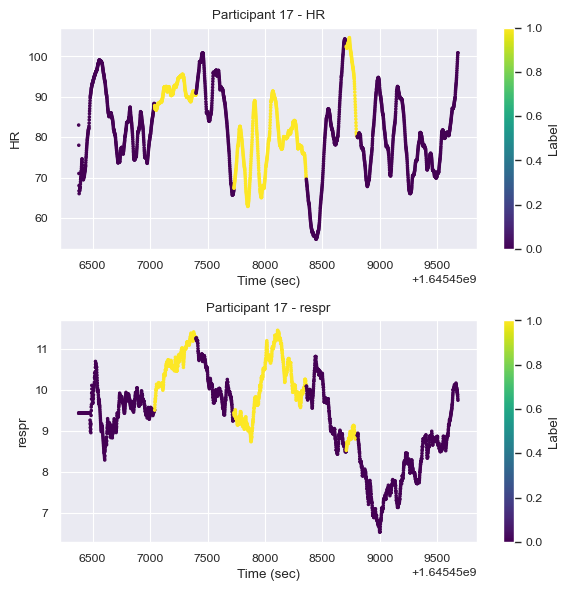

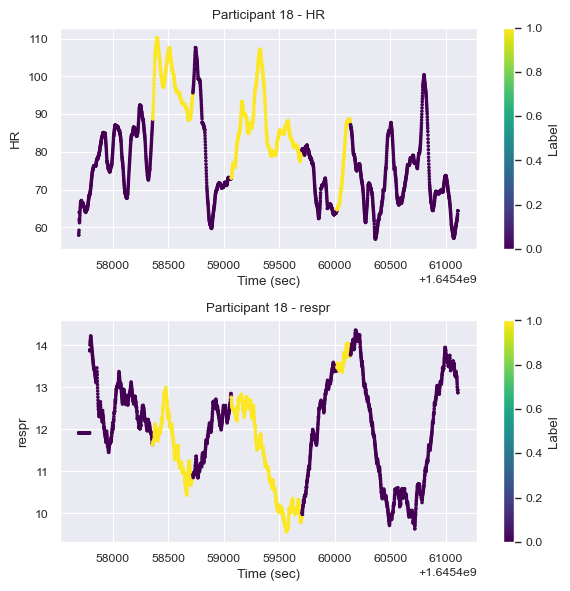

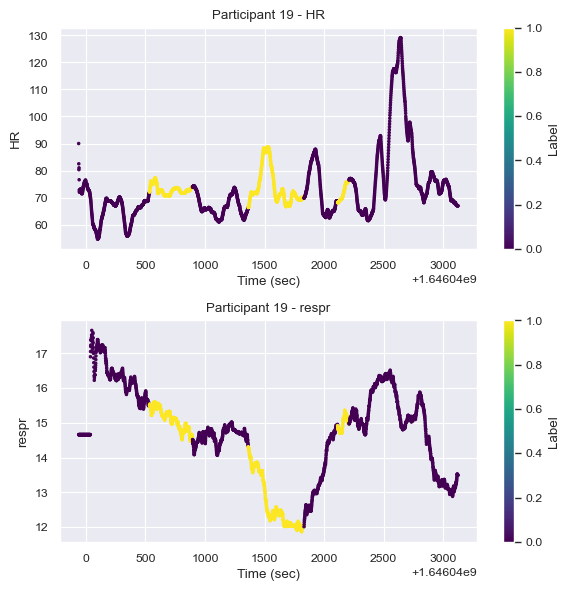

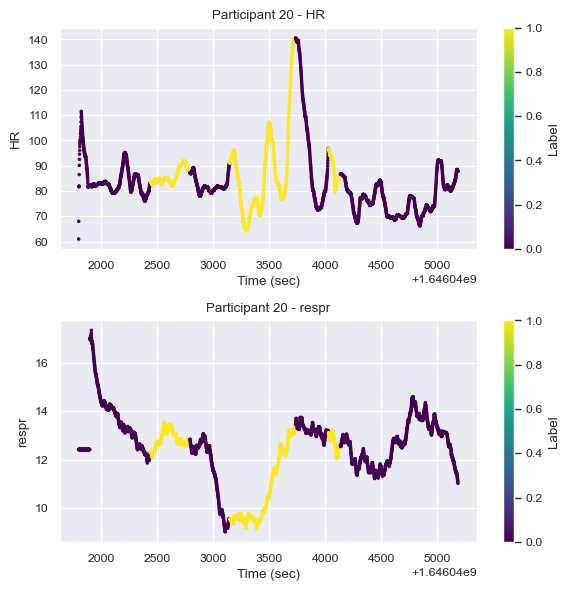

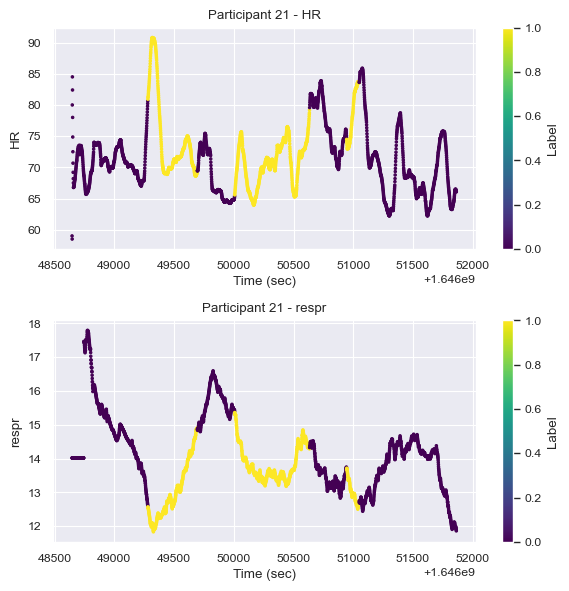

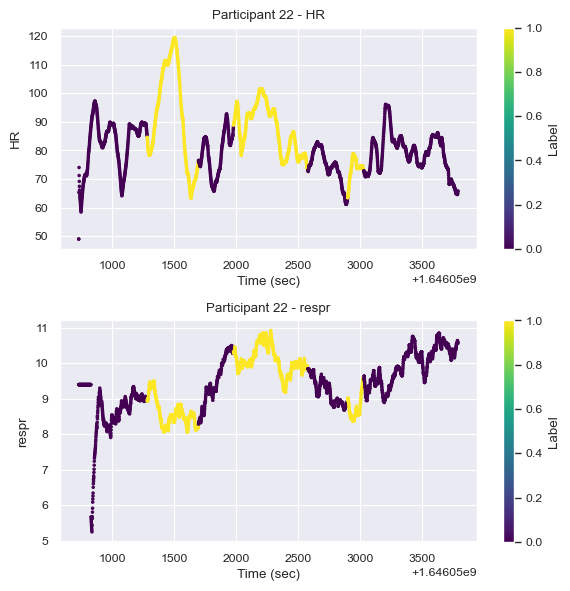

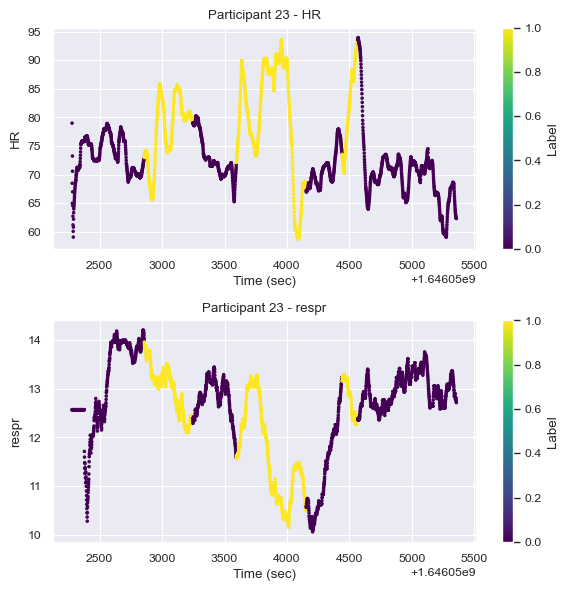

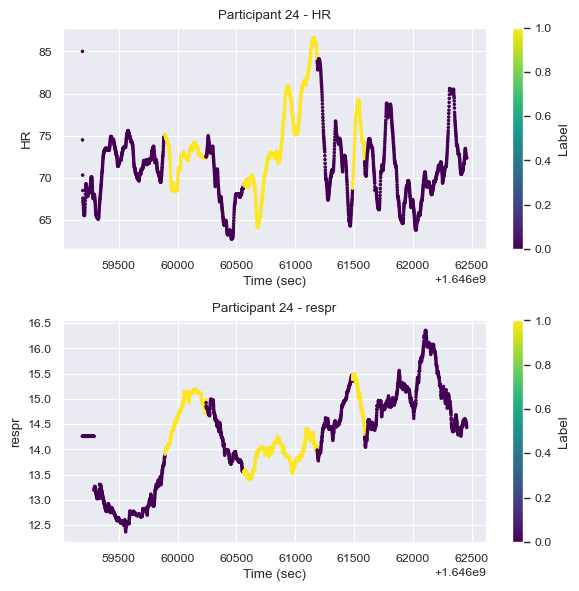

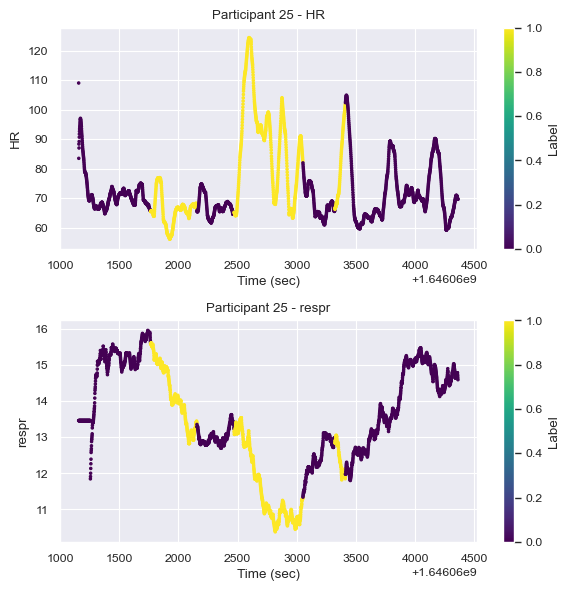

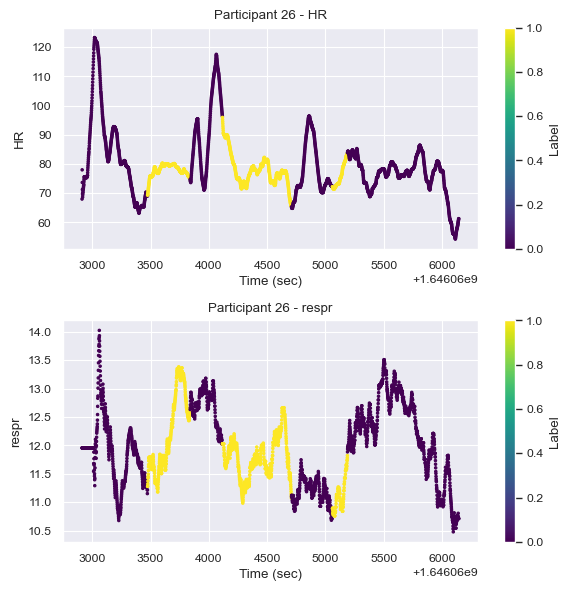

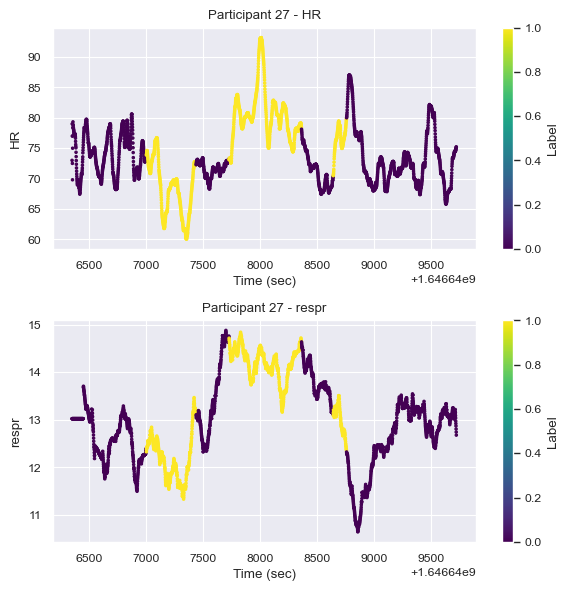

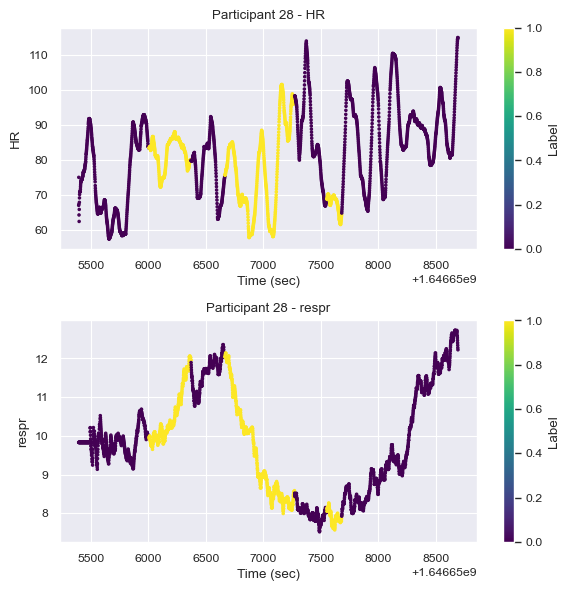

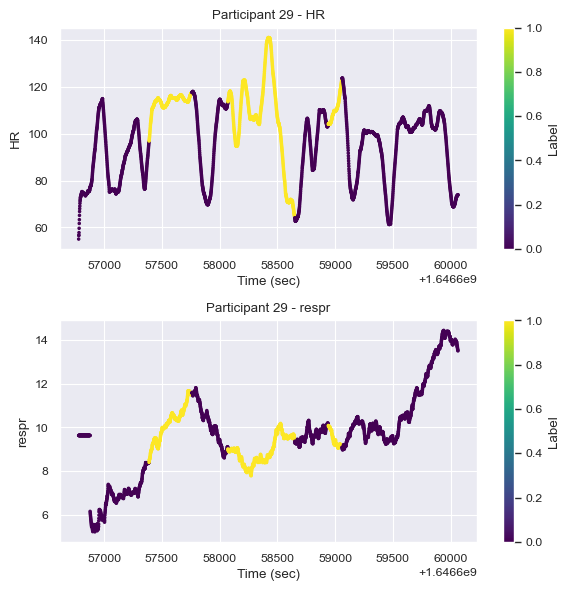

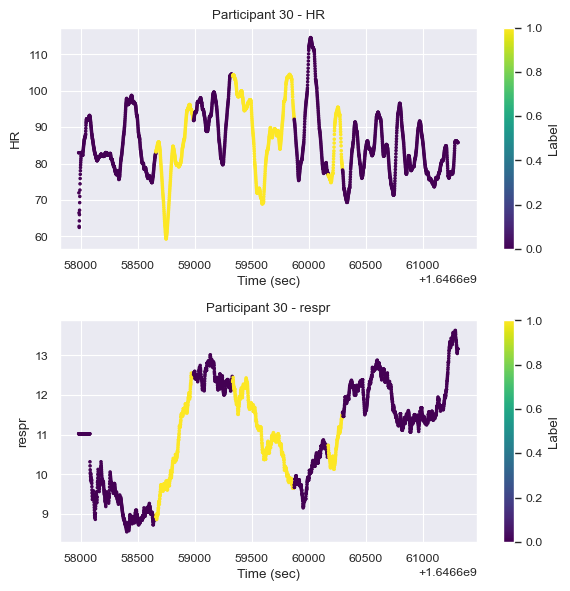

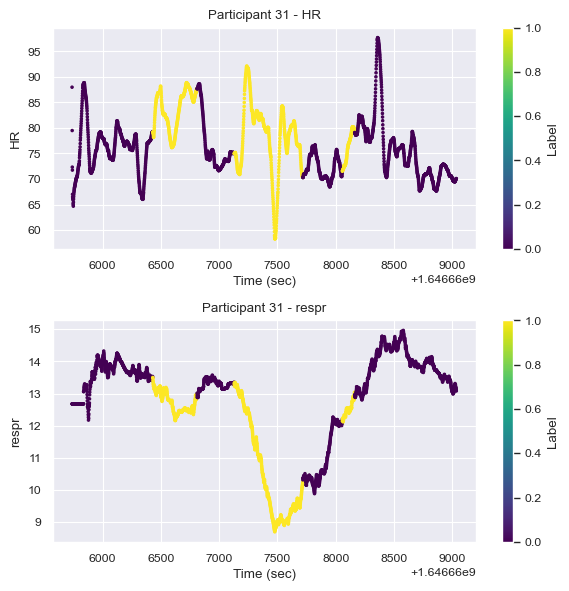

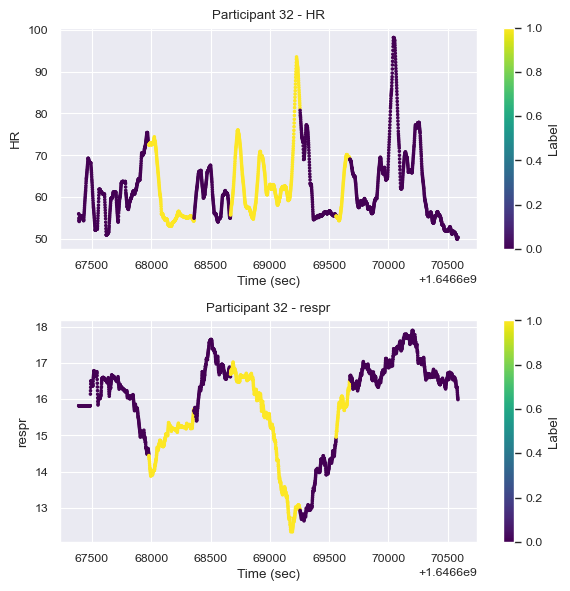

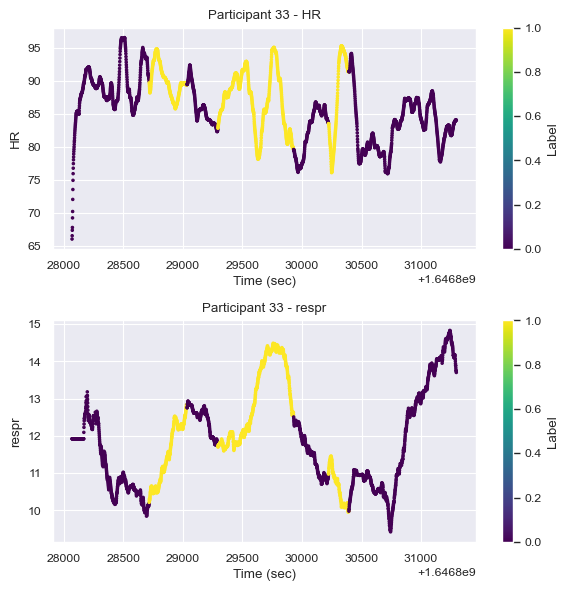

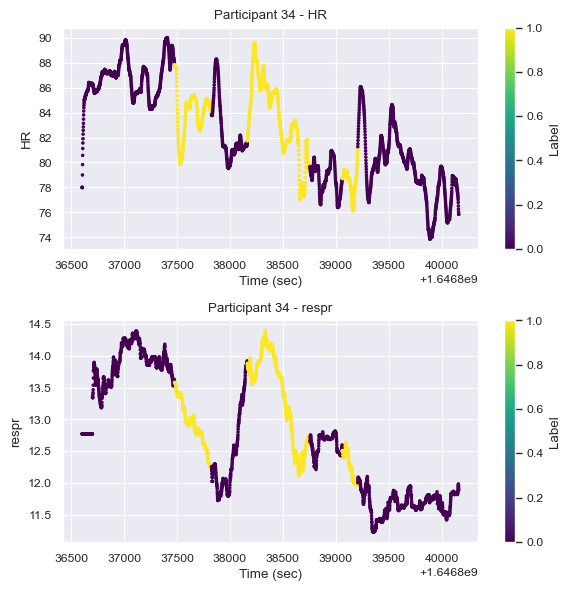

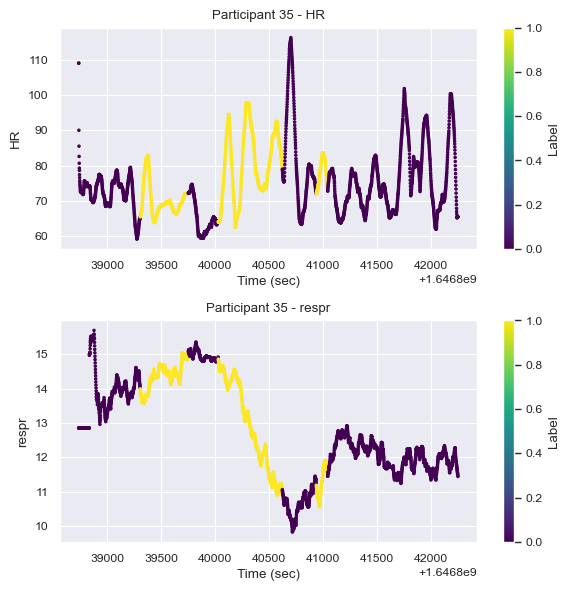

In [34]:
from matplotlib import pyplot as plt

# Plot HR and respr for each participant with color based on label
for participant in participants:
    participant_data = data[data['Participant'] == participant]

    plt.figure(figsize=(6, 6))

    # Plot HR with label color
    plt.subplot(2, 1, 1)
    scatter = plt.scatter(participant_data['Time(sec)'], participant_data['HR'], c=participant_data['Label'], cmap='viridis', s=3)
    plt.title(f'Participant {participant} - HR')
    plt.xlabel('Time (sec)')
    plt.ylabel('HR')
    plt.colorbar(scatter, label='Label')

    # Plot respr with label color
    plt.subplot(2, 1, 2)
    scatter = plt.scatter(participant_data['Time(sec)'], participant_data['respr'], c=participant_data['Label'], cmap='viridis', s=3)
    plt.title(f'Participant {participant} - respr')
    plt.xlabel('Time (sec)')
    plt.ylabel('respr')
    plt.colorbar(scatter, label='Label')

    plt.tight_layout()
    plt.show()

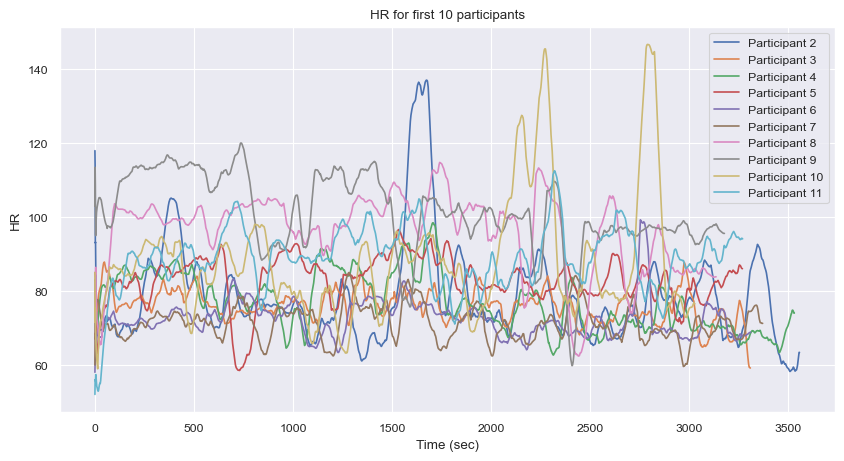

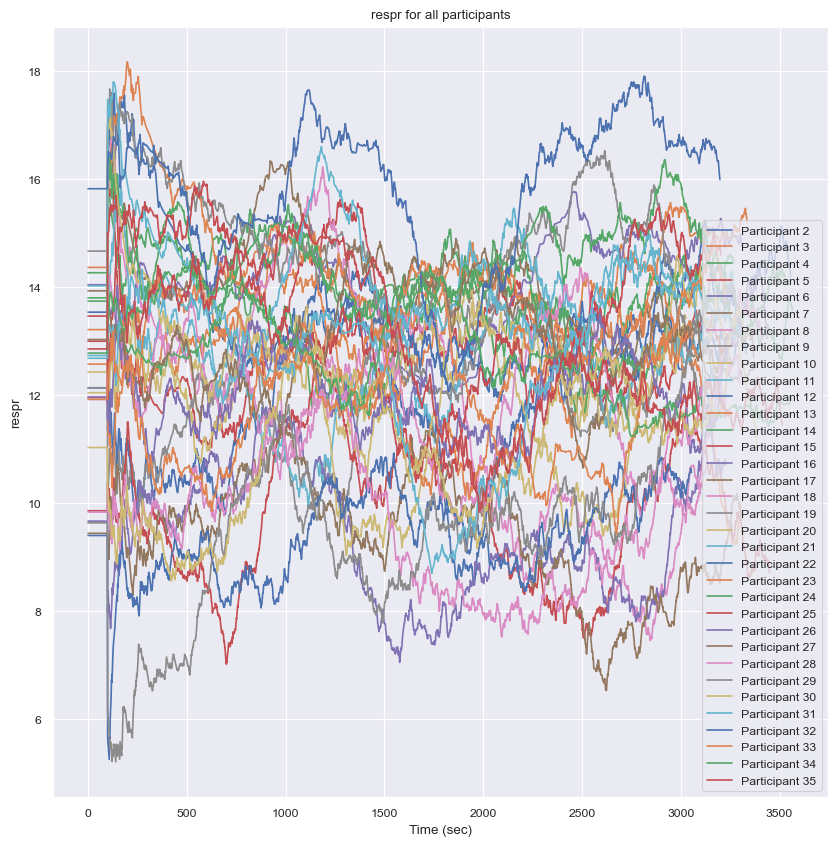

In [59]:
from matplotlib import pyplot as plt

# Plot HR for all participants
plt.figure(figsize=(10, 5))
for participant in range(2, 12):
    participant_data = data[data['Participant'] == participant]
    participant_data.loc[:, 'Time(sec)'] = participant_data['Time(sec)'] - participant_data['Time(sec)'].min()
    plt.plot(participant_data['Time(sec)'], participant_data['HR'], label=f'Participant {participant}')
plt.title('HR for first 10 participants')
plt.xlabel('Time (sec)')
plt.ylabel('HR')
plt.legend()
plt.savefig("hr_data.png")
plt.show()

# Plot respr for all participants
plt.figure(figsize=(10, 10))
for participant in participants:
    participant_data = data[data['Participant'] == participant]
    participant_data.loc[:, 'Time(sec)'] = participant_data['Time(sec)'] - participant_data['Time(sec)'].min()
    plt.plot(participant_data['Time(sec)'], participant_data['respr'], label=f'Participant {participant}')
plt.title('respr for all participants')
plt.xlabel('Time (sec)')
plt.ylabel('respr')
plt.legend()
plt.show()

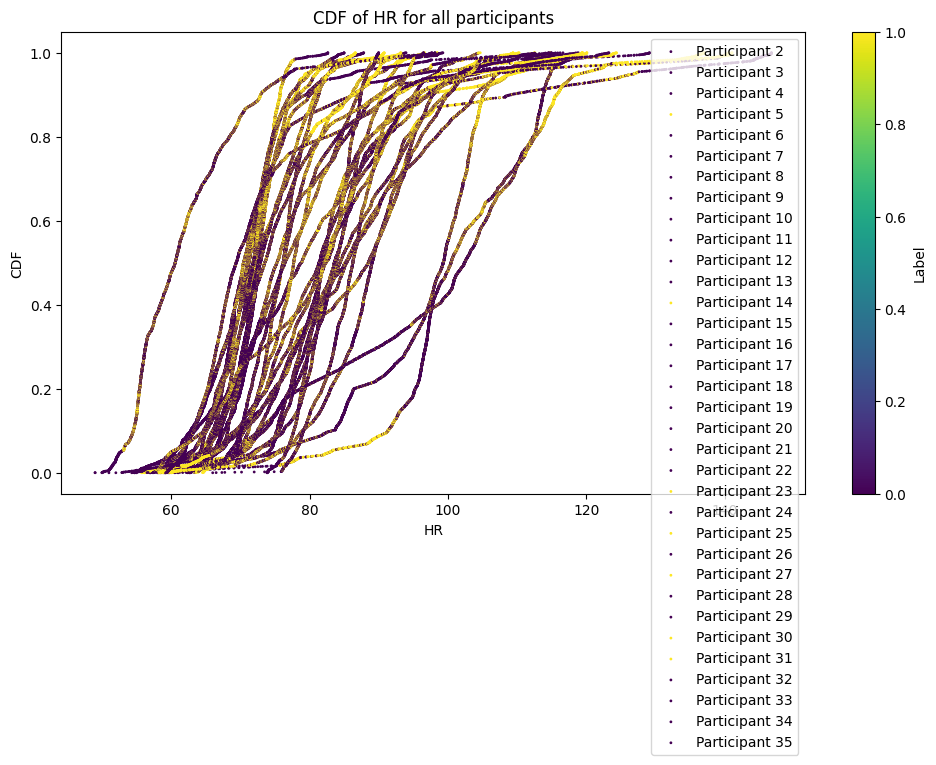

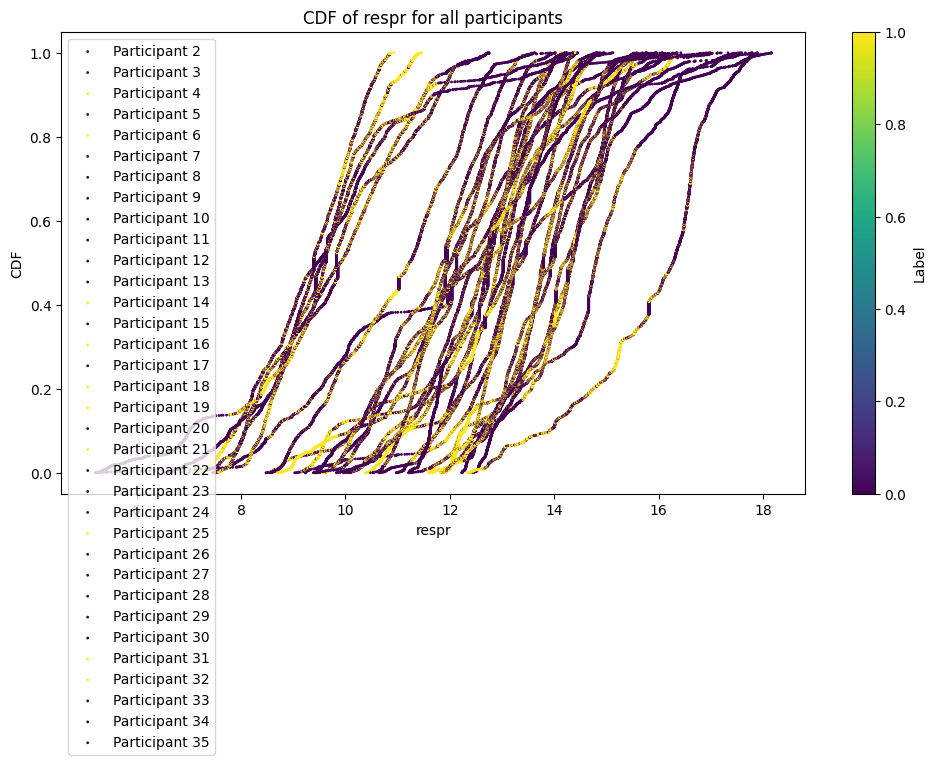

In [35]:
import numpy as np

# Plot CDF for each participant with label colors
plt.figure(figsize=(12, 6))
for participant in participants:
    participant_data = data[data['Participant'] == participant]
    hr_sorted = np.sort(participant_data['HR'])
    cdf = np.arange(1, len(hr_sorted) + 1) / len(hr_sorted)
    scatter = plt.scatter(hr_sorted, cdf, c=participant_data['Label'].iloc[np.argsort(participant_data['HR'])], cmap='viridis', s=1, label=f'Participant {participant}')
plt.title('CDF of HR for all participants')
plt.xlabel('HR')
plt.ylabel('CDF')
plt.colorbar(scatter, label='Label')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
for participant in participants:
    participant_data = data[data['Participant'] == participant]
    respr_sorted = np.sort(participant_data['respr'])
    cdf = np.arange(1, len(respr_sorted) + 1) / len(respr_sorted)
    scatter = plt.scatter(respr_sorted, cdf, c=participant_data['Label'].iloc[np.argsort(participant_data['respr'])], cmap='viridis', s=1, label=f'Participant {participant}')
plt.title('CDF of respr for all participants')
plt.xlabel('respr')
plt.ylabel('CDF')
plt.colorbar(scatter, label='Label')
plt.legend()
plt.show()